# Customer Behavior EDA

Objective: Analyze customer ordering cadence, reorder intensity, and basket behavior.

In [13]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

USE_SAMPLE = True
df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 9,356 records with 934 unique customers
Date range: 2015-06-01 to 2015-07-01
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,total_price,cumulative_reorder_per_customer
0,2127348,42489,1,1,52,prior,26,5,13,18.0,18.0,2015-06-13,Organic Raw Walnut Banana Meals To-Go,1,1
1,2127348,43352,2,0,52,prior,26,5,13,18.0,18.0,2015-06-13,Raspberries,1,1
2,2127348,40063,3,1,52,prior,26,5,13,18.0,18.0,2015-06-13,Gluten Free Chocolate Chip Cookies,1,2
3,2127348,8048,4,1,52,prior,26,5,13,18.0,18.0,2015-06-13,Packaged Grape Tomatoes,1,3
4,2127348,46516,5,1,52,prior,26,5,13,18.0,18.0,2015-06-13,Sesame Bagels,1,4


## Analysis Questions
- Do customers who reorder have shorter days between orders?
- Do high-order-history customers reorder more?
- How strongly does cumulative reorder history separate behavior groups?

In [3]:
customer_kpi = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        cumulative_reorder_last=("cumulative_reorder_per_customer", "max"),
    )
    .reset_index()
)

display(customer_kpi.describe(include="all"))

summary_by_reordered = (
    df.groupby("reordered")
    .agg(
        avg_days_since_prior_order=("days_since_prior_order", "mean"),
        median_order_number=("order_number", "median"),
        median_cumulative_reorder=("cumulative_reorder_per_customer", "median"),
        sample_size=("order_id", "count"),
    )
)
summary_by_reordered

,user_id,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
count,934.000000,934.00000,934.000000,934.000000,934.000000,934.000000
mean,102646.137045,16.64561,10.017131,0.594517,9.784480,5.938972
std,58553.666110,17.36370,7.207811,0.333806,8.848809,5.734901
min,52.000000,1.00000,1.000000,0.000000,0.000000,0.000000
25%,51330.000000,4.00000,5.000000,0.333333,3.000000,2.000000
50%,102861.500000,10.00000,8.000000,0.625000,7.000000,4.000000
75%,153112.750000,23.00000,14.000000,0.894737,13.750000,8.000000
max,206074.000000,99.00000,44.000000,1.000000,30.000000,33.000000


,avg_days_since_prior_order,median_order_number,median_cumulative_reorder,sample_size
reordered,,,,
0,9.783408,6.0,2.0,3809
1,9.700559,16.0,5.0,5547


## Bivariate Comparison

This section was moved from the overview notebook and consolidated here for customer behavior interpretation.

## - Reorder Behavior

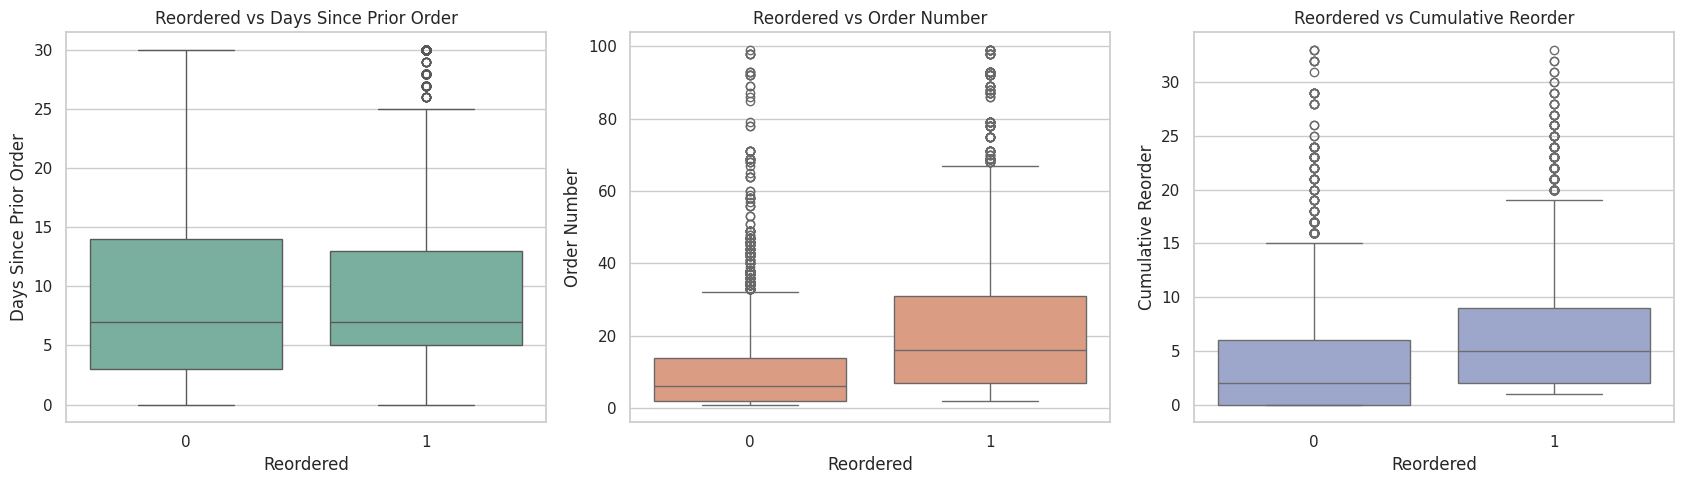

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(x="reordered", y="days_since_prior_order", data=df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [5]:
# Compare metrics between reordered and non-reordered items
reordered_yes = df[df["reordered"] == 1]
reordered_no = df[df["reordered"] == 0]

comparison_stats = {
    "days_since_prior_order": reordered_yes["days_since_prior_order"].mean() - reordered_no["days_since_prior_order"].mean(),
    "order_number": reordered_yes["order_number"].median() - reordered_no["order_number"].median(),
    "cumulative_reorder": reordered_yes["cumulative_reorder_per_customer"].median() - reordered_no["cumulative_reorder_per_customer"].median(),
}

pd.Series(comparison_stats, name="difference").to_frame()

,difference
days_since_prior_order,-0.082849
order_number,10.000000
cumulative_reorder,3.000000


## Key Insight Notes
- If days_since_prior_order difference is negative, reordered users tend to come back sooner.
- Positive median order_number difference indicates reorders increase with customer order history.
- Positive cumulative_reorder median difference indicates reorder behavior is reinforced over time.

## - Order & Reorder Behavior / Day time 

In [6]:
order_level = (
    df.groupby("order_id")
    .agg(
        order_dow=("order_dow", "first"),
        order_hour_of_day=("order_hour_of_day", "first"),
        total_products=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        days_since_prior_order=("days_since_prior_order", "first"),
    )
    .reset_index()
)

print("Order-Level Summary:")
display(order_level.drop(columns=["order_id"]).describe(include="all"))

Order-Level Summary:


,order_dow,order_hour_of_day,total_products,reorder_rate,days_since_prior_order
count,938.000000,938.000000,938.000000,938.000000,938.000000
mean,2.637527,13.529851,9.974414,0.595033,9.768657
std,2.003934,4.179748,7.137720,0.334884,8.835313
min,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,10.000000,5.000000,0.333333,3.000000
50%,2.000000,13.000000,8.000000,0.625000,7.000000
75%,4.000000,16.000000,13.000000,0.900000,13.000000
max,6.000000,23.000000,44.000000,1.000000,30.000000


In [7]:
day_map = {
    0: "Sun", 1: "Mon", 2: "Tue",
    3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"
}

order_level["day_name"] = order_level["order_dow"].map(day_map)
order_level["day_name"] = pd.Categorical(
    order_level["day_name"],
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True
)

customer_kpi = (
    order_level.groupby(["day_name", "order_hour_of_day"], observed=False)
    .agg(
        avg_orders=("order_id", "count"),
        avg_products_per_order=("total_products", "mean"),
        avg_reorder_rate=("reorder_rate", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
    )
    .reset_index()
    .sort_values(["day_name", "order_hour_of_day"])
)

print("Order-Customer KPI Summary:")
display(customer_kpi.describe(include="all"))

Order-Customer KPI Summary:


,day_name,order_hour_of_day,avg_orders,avg_products_per_order,avg_reorder_rate,avg_days_between_orders
count,154,154.000000,154.000000,130.000000,130.000000,130.000000
unique,7,NaN,NaN,NaN,NaN,NaN
top,Sun,NaN,NaN,NaN,NaN,NaN
freq,22,NaN,NaN,NaN,NaN,NaN
mean,NaN,12.318182,6.090909,10.074437,0.604520,9.268553
std,NaN,6.671277,5.161906,4.028443,0.161049,3.832396
min,NaN,0.000000,0.000000,1.000000,0.000000,0.000000
25%,NaN,7.000000,2.000000,8.000000,0.511111,7.000000
50%,NaN,12.500000,5.000000,9.625000,0.590854,9.400568
75%,NaN,18.000000,10.000000,11.809524,0.683141,11.534091


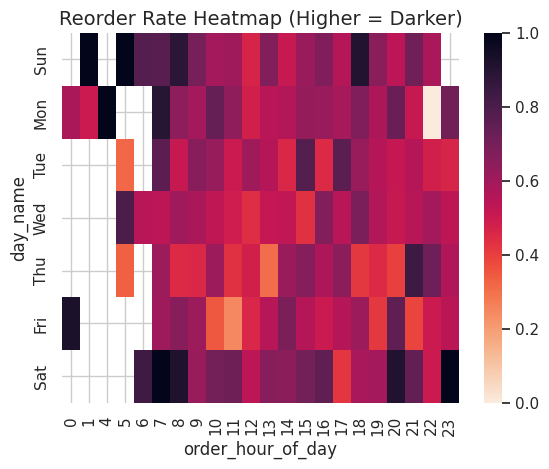

In [8]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="avg_reorder_rate"
)

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Reorder Rate Heatmap (Higher = Darker)", fontsize=14)
plt.show()

<Axes: xlabel='order_hour_of_day', ylabel='avg_reorder_rate'>

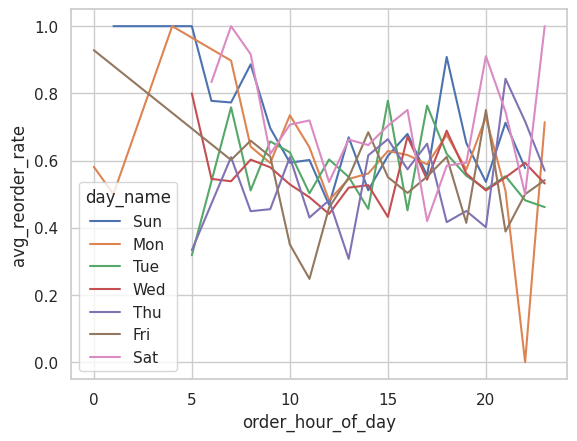

In [9]:
sns.lineplot(
    data=customer_kpi,
    x="order_hour_of_day",
    y="avg_reorder_rate",
    hue="day_name"
    )

<Axes: xlabel='day_name', ylabel='reorder_rate'>

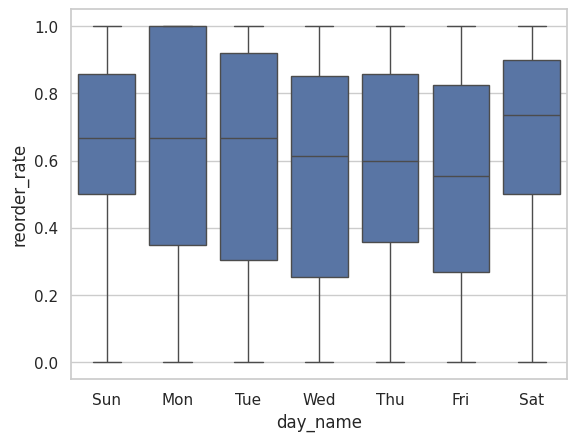

In [10]:
sns.boxplot(
    data=order_level,
    x="day_name",
    y="reorder_rate"
    )

## Segmentation Analysis

### 1 . Customer segmentation (RFM, cohort groups)

การแบ่งกลุ่มลูกค้า

RFM = Recency, Frequency, Monetary
- Recency → ลูกค้าซื้อล่าสุดเมื่อไหร่
- Frequency → ซื้อบ่อยแค่ไหน
- Monetary → ใช้เงินเยอะแค่ไหน
ใช้แบ่งลูกค้าเป็น: (VIP / Loyal, ลูกค้าใหม่, ลูกค้าที่กำลังจะหาย)

ส่วน Cohort group

คือการแบ่งตาม “ช่วงเวลาเริ่มใช้งาน”
เช่น ลูกค้าที่สมัครเดือนเดียวกัน

### -Rate Of Number of Purchase each Product Name

In [14]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("user_id")
    .agg(
        recency=("order_date", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("total_price", "median"),
    )
    .reset_index()
)

rfm["recency_score"] = pd.qcut(
    rfm["recency"].rank(method="first", ascending=False),
    q=4,
    labels=[1, 2, 3, 4],
)
rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
)
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
)

rfm["rfm_score"] = (
    rfm["recency_score"].astype(int)
    + rfm["frequency_score"].astype(int)
    + rfm["monetary_score"].astype(int)
)
rfm["segment"] = pd.cut(
    rfm["rfm_score"],
    bins=[0, 5, 8, 12],
    labels=["At Risk", "Regular", "Loyal"],
    include_lowest=True,
)

rfm.head()

,user_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,segment
0,52,19,1,1.0,1,1,1,3,At Risk
1,551,16,1,1.0,1,1,1,3,At Risk
2,729,8,1,1.0,2,1,1,4,At Risk
3,997,24,1,1.0,1,1,1,3,At Risk
4,1951,9,1,1.0,2,1,1,4,At Risk


### 2. Product preferences by customer segment
Use the transaction-level dataset joined with the RFM segment labels, because product fields do not exist in the aggregated `rfm` table.

ลูกค้าแต่ละกลุ่มชอบสินค้าอะไร
ตัวอย่าง:

- VIP → ชอบสินค้าแพง
- ลูกค้าใหม่ → ชอบของลดราคา`

💡 ใช้ทำ:
- Recommendation
- Marketing targeting

### - Rate 

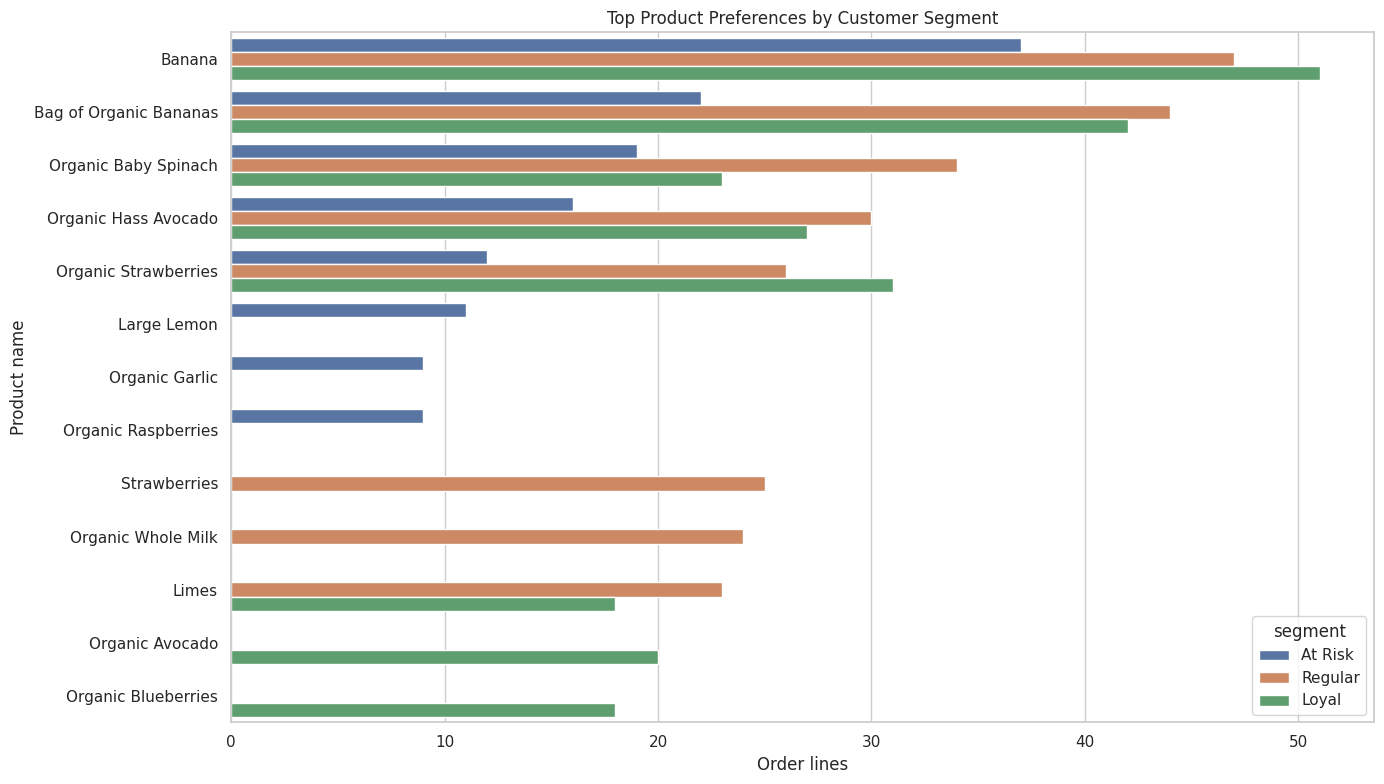

,segment,product_name,order_lines
0,At Risk,Banana,37
1,At Risk,Bag of Organic Bananas,22
2,At Risk,Organic Baby Spinach,19
3,At Risk,Organic Hass Avocado,16
4,At Risk,Organic Strawberries,12
5,At Risk,Large Lemon,11
6,At Risk,Organic Garlic,9
7,At Risk,Organic Raspberries,9
8,Regular,Banana,47
9,Regular,Bag of Organic Bananas,44


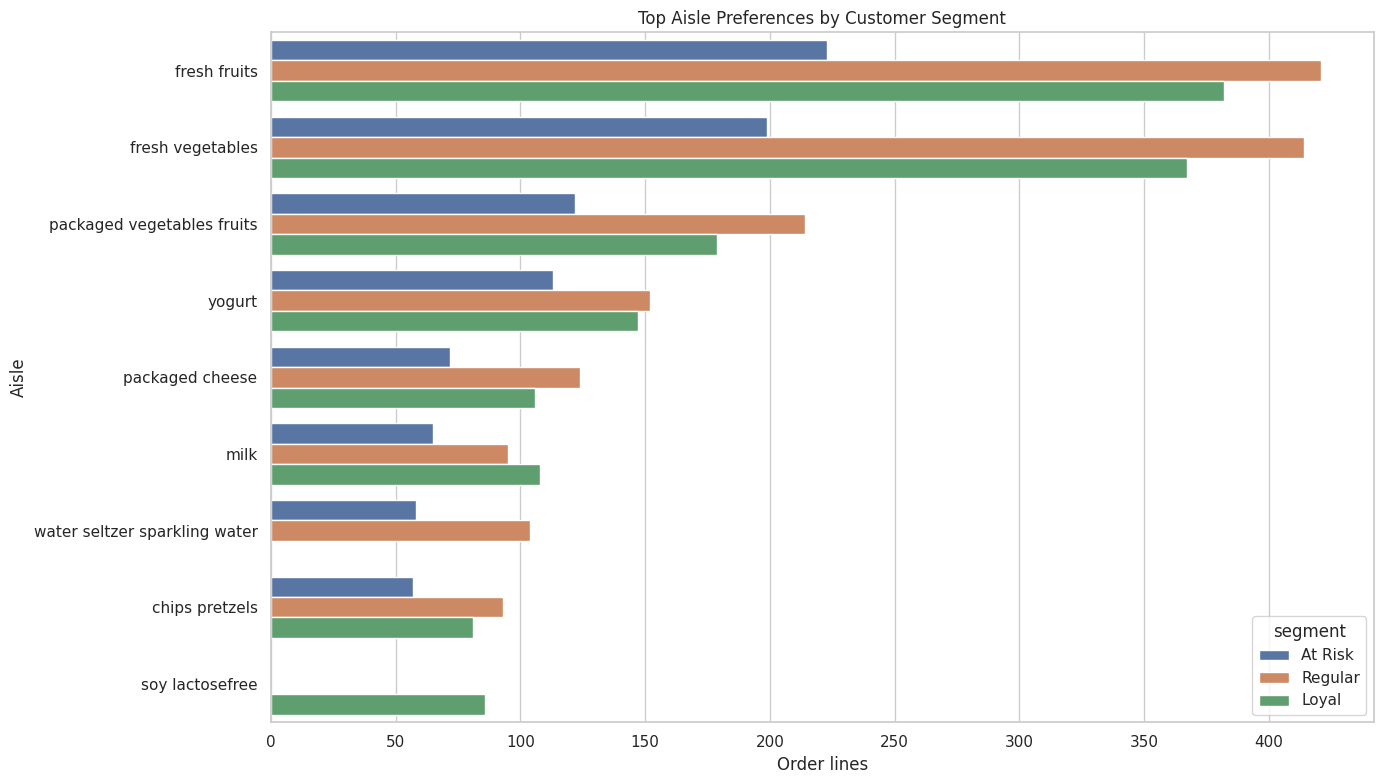

,segment,aisle,order_lines
0,At Risk,fresh fruits,223
1,At Risk,fresh vegetables,199
2,At Risk,packaged vegetables fruits,122
3,At Risk,yogurt,113
4,At Risk,packaged cheese,72
5,At Risk,milk,65
6,At Risk,water seltzer sparkling water,58
7,At Risk,chips pretzels,57
8,Regular,fresh fruits,421
9,Regular,fresh vegetables,414


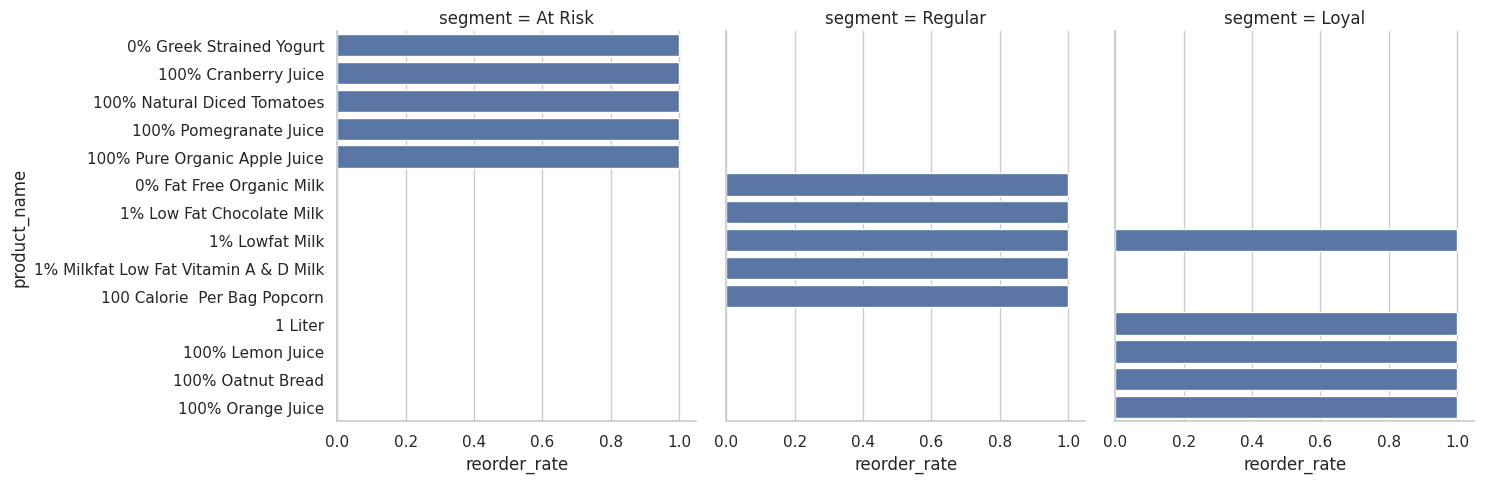

,segment,product_name,order_lines,reorder_rate
0,At Risk,0% Greek Strained Yogurt,1,1.0
3,At Risk,100% Cranberry Juice,1,1.0
5,At Risk,100% Natural Diced Tomatoes,1,1.0
6,At Risk,100% Pomegranate Juice,1,1.0
7,At Risk,100% Pure Organic Apple Juice,1,1.0
1502,Regular,0% Fat Free Organic Milk,1,1.0
1504,Regular,1% Low Fat Chocolate Milk,1,1.0
1505,Regular,1% Lowfat Milk,1,1.0
1506,Regular,1% Milkfat Low Fat Vitamin A & D Milk,1,1.0
1507,Regular,100 Calorie Per Bag Popcorn,1,1.0


In [16]:
segment_txn = df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

# Ensure aisle exists for aisle-level preference analysis.
if "aisle" not in segment_txn.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "aisle"]]
    segment_txn = segment_txn.merge(product_dim, on="product_id", how="left")

segment_product_pref = (
    segment_txn.groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

segment_aisle_pref = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_aisle_by_segment = (
    segment_aisle_pref.sort_values(
        ["segment", "order_lines", "aisle"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

top_reordered_by_segment = (
    segment_txn.groupby(["segment", "product_name"])
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

top_reordered_by_segment = (
    top_reordered_by_segment
    .sort_values(["segment", "reorder_rate"], ascending=[True, False])
    .groupby("segment")
    .head(5)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

display(top_products_by_segment)



plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_aisle_by_segment,
    x="order_lines",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

display(top_aisle_by_segment)


sns.catplot(
    data=top_reordered_by_segment,
    x="reorder_rate",
    y="product_name",
    col="segment",
    kind="bar",
    height=5,
    aspect=1
)
plt.show()

display(top_reordered_by_segment)

### 3. Retention / Churn analysis

### 4. Basket value or repeat rate by product category

### 5. Customer lifetime value (CLV) trends